In [4]:
# Load libraries
import torch
import torch.nn as nn
from res.plot_lib import set_default, show_scatterplot, plot_bases
from matplotlib.pyplot import plot, title, axis

In [5]:
# Set style (needs to be in a new cell)
set_default()

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

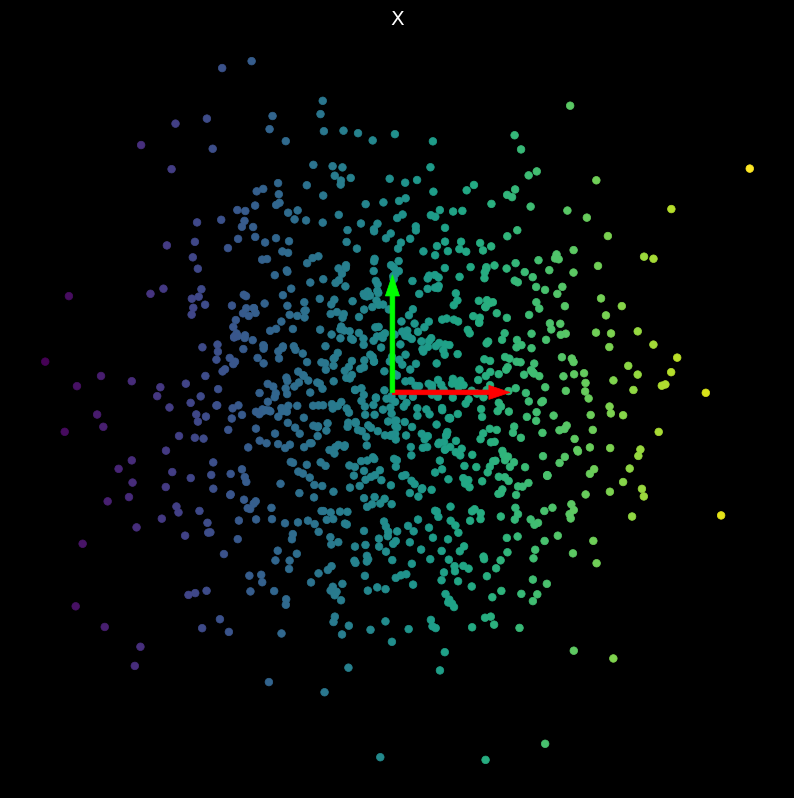

In [7]:
# generate some points in 2-D space
n_points = 1000
X = torch.randn(n_points, 2).to(device)
colors = X[:, 0]

show_scatterplot(X, colors, title='X')
OI = torch.cat((torch.zeros(2, 2), torch.eye(2))).to(device)
plot_bases(OI)
#OI

# Visualizing Linear Transformations

* Generate a random matrix $W$

$
\begin{equation}
    W = U
  \left[ {\begin{array}{cc}
   s_1 & 0 \\
   0 & s_2 \\
  \end{array} } \right]
  V^\top
\end{equation}
$
* Compute $y = Wx$
* Larger singular values stretch the points
* Smaller singular values push them together
* $U, V$ rotate/reflect

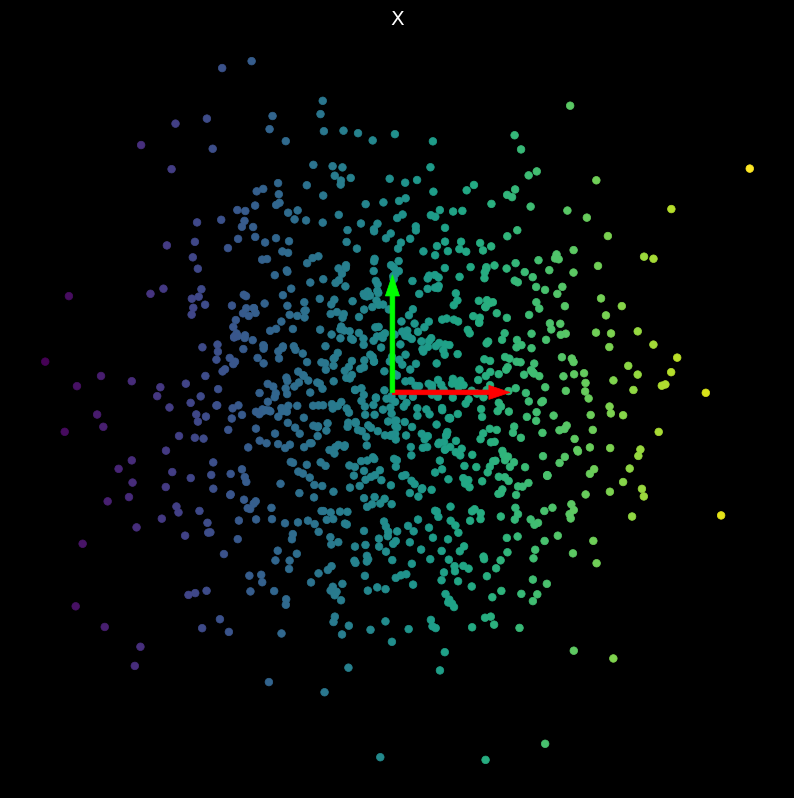

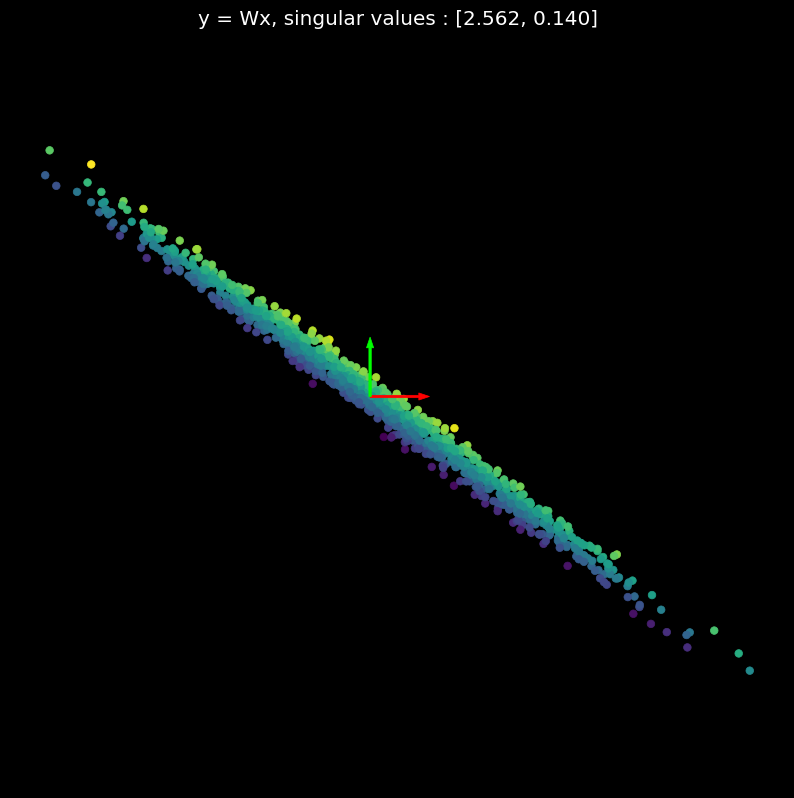

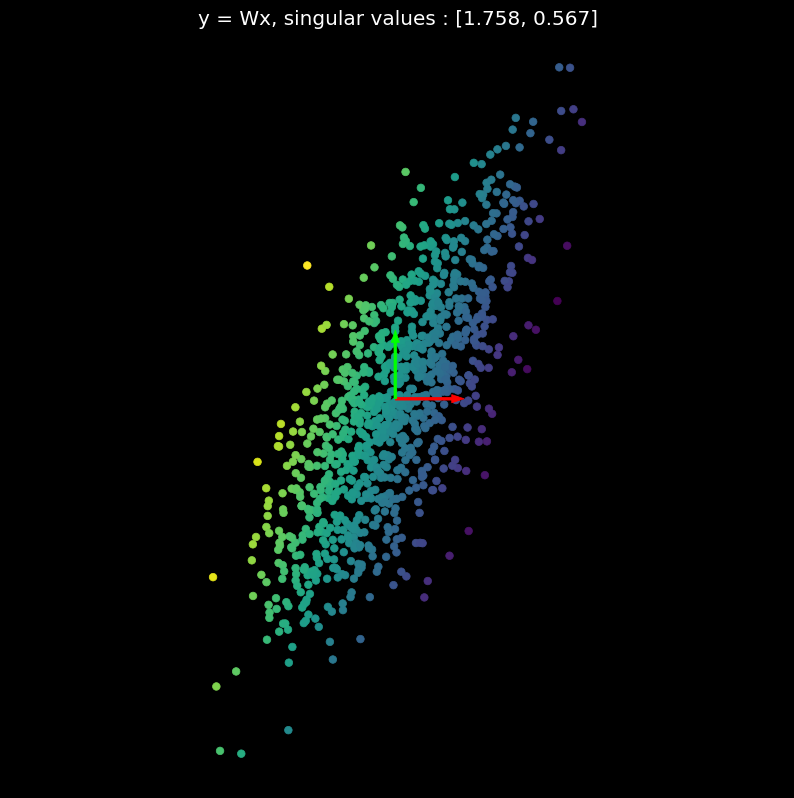

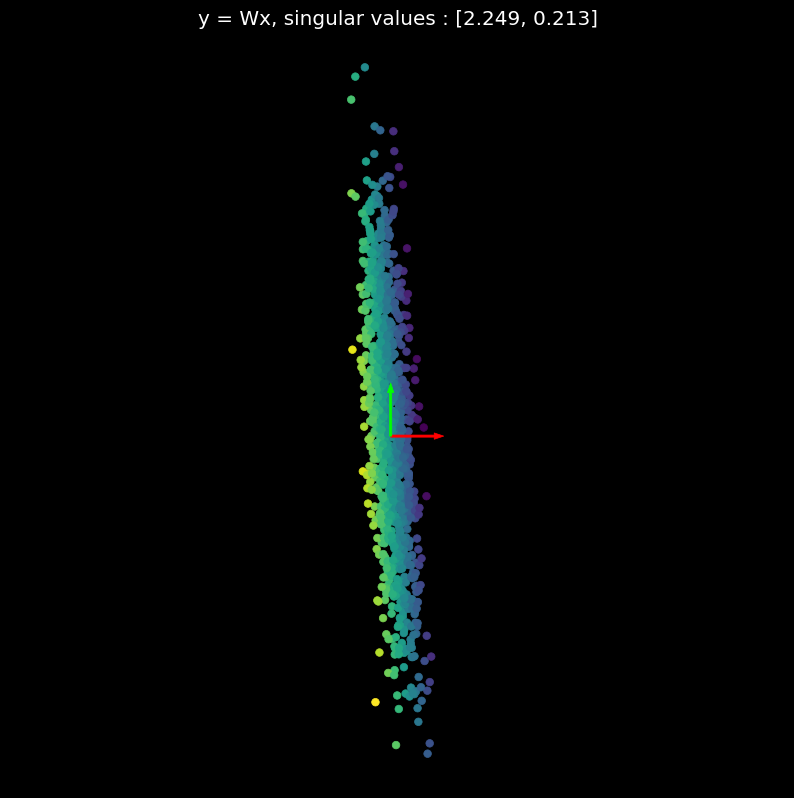

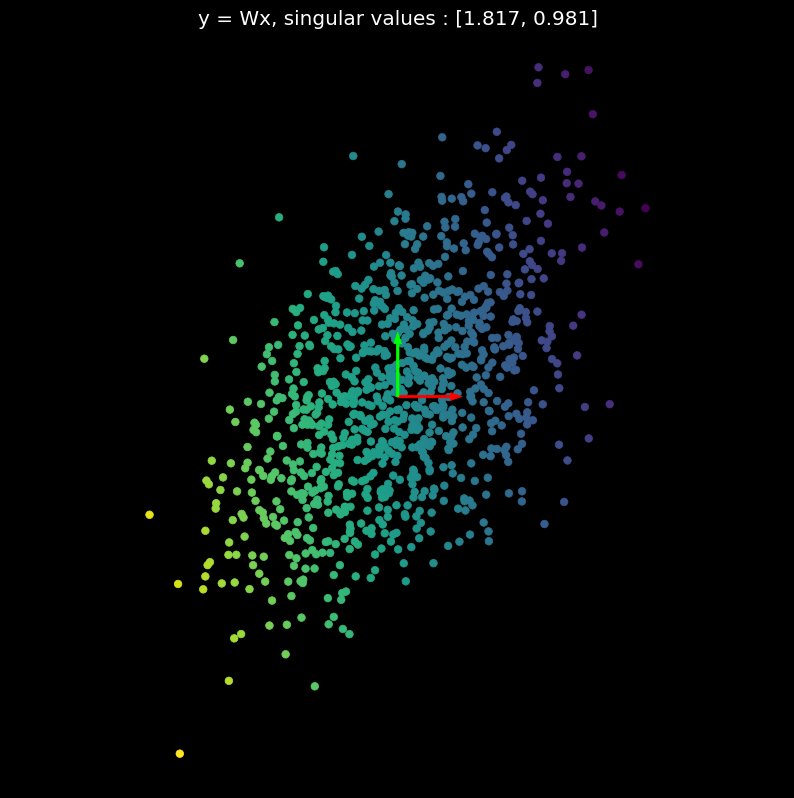

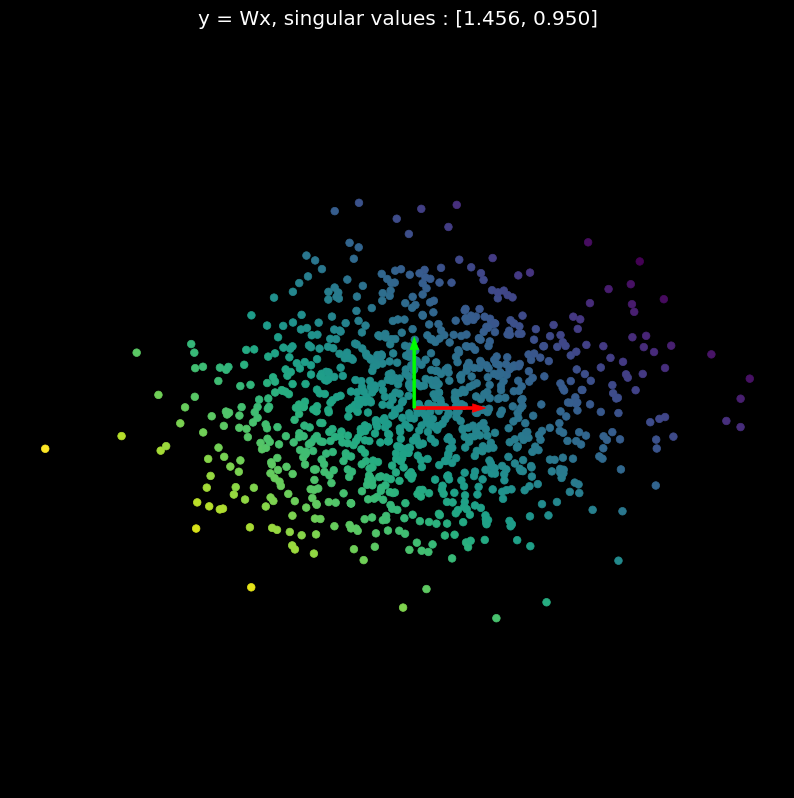

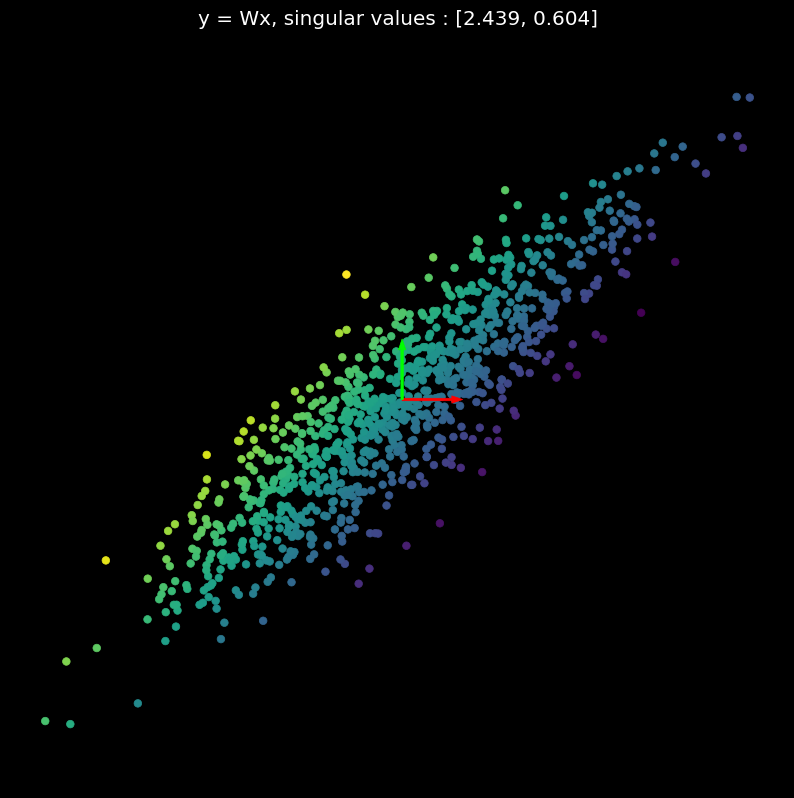

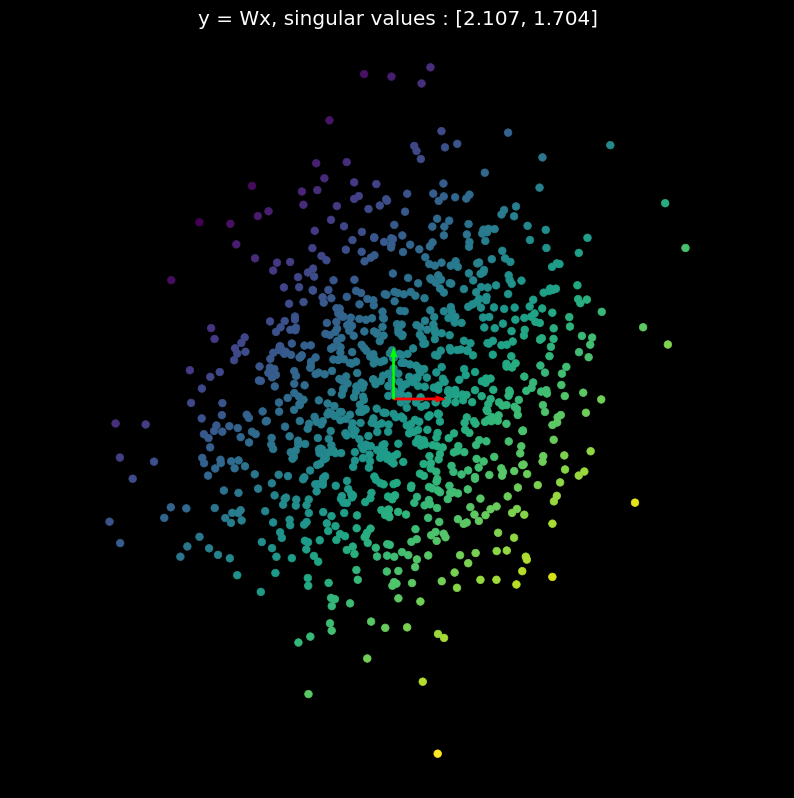

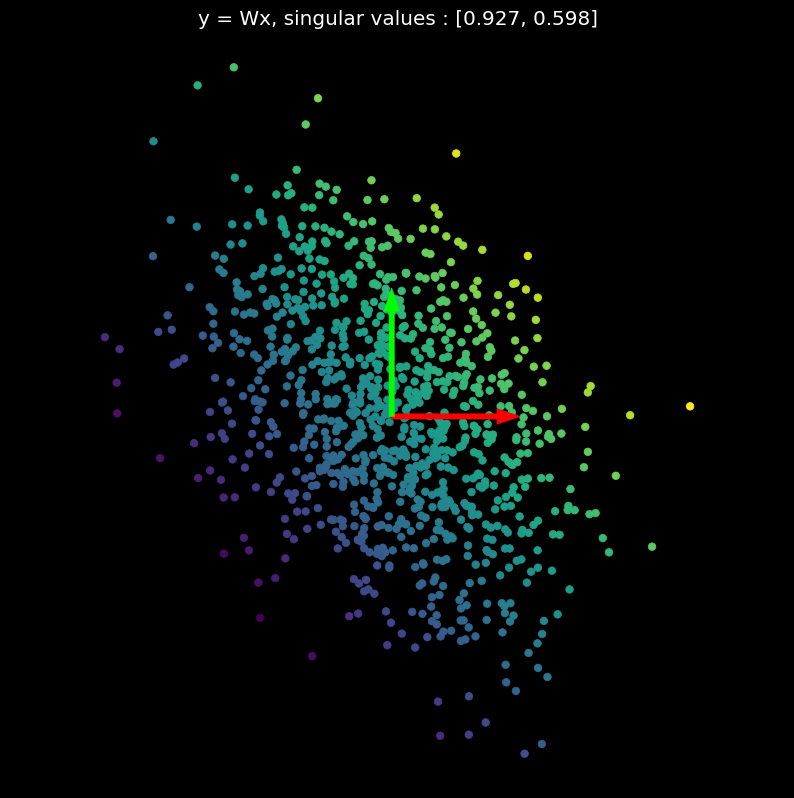

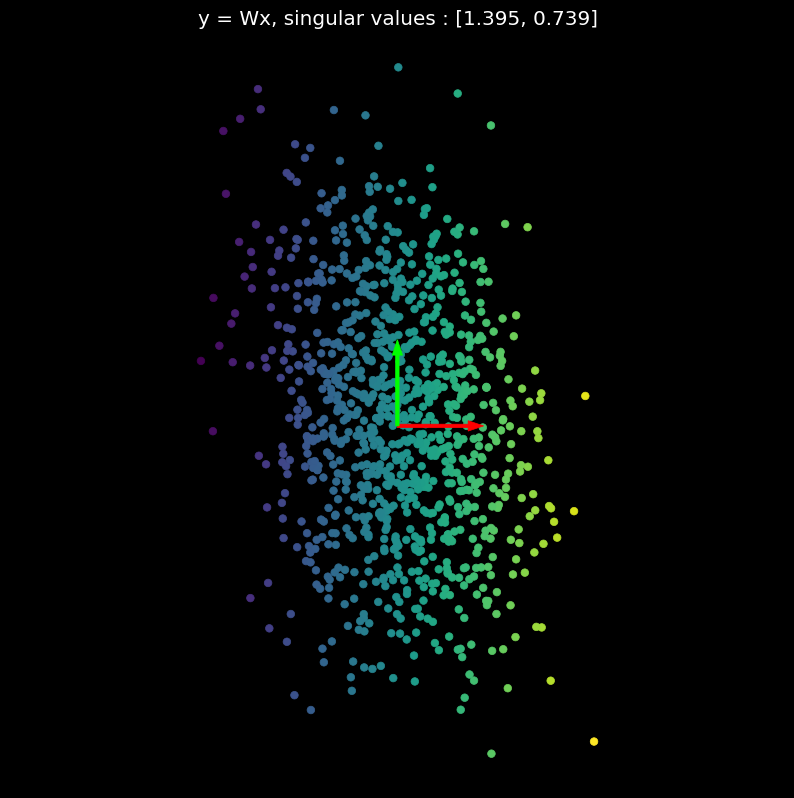

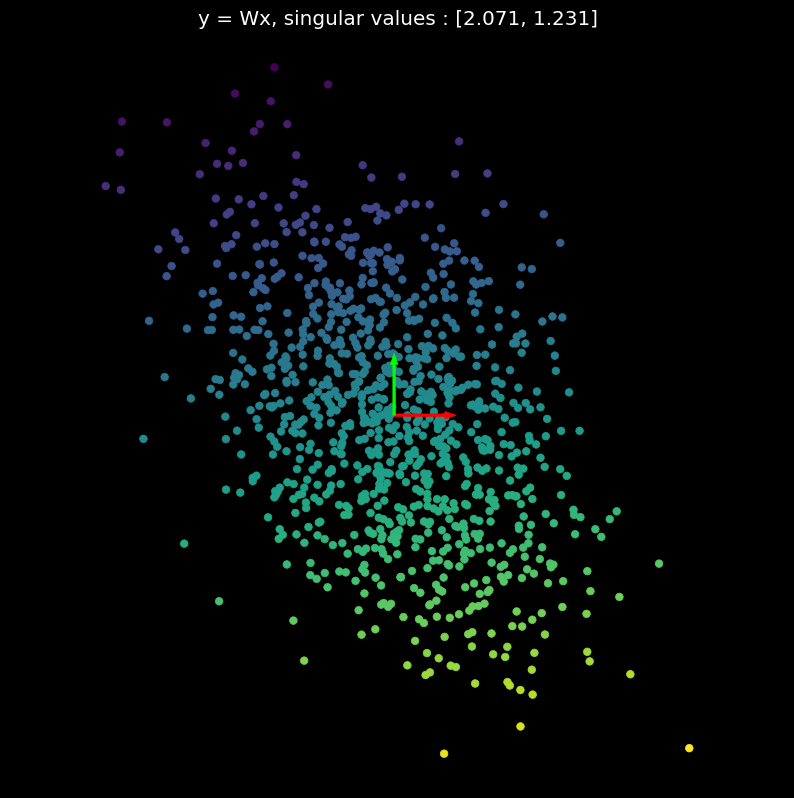

In [8]:
show_scatterplot(X, colors, title='X')
plot_bases(OI)

for i in range(10):
    # create a random matrix
    W = torch.randn(2, 2).to(device)
    # transform points
    Y = X @ W.t()
    #Y=W@X
    # compute singular values
    U, S, V = torch.svd(W)
    # plot transformed points
    show_scatterplot(Y, colors, title='y = Wx, singular values : [{:.3f}, {:.3f}]'.format(S[0], S[1]))
    # transform the basis
    new_OI = OI @ W.t()
    # plot old and new basis
    plot_bases(OI)
#     plot_bases(new_OI)

# Linear transformation with PyTorch

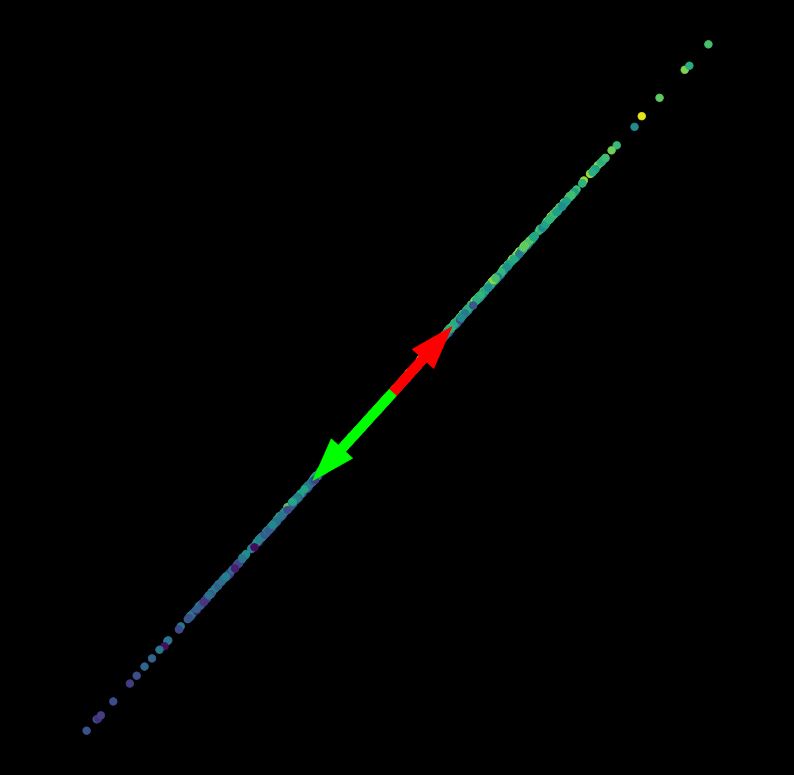

In [9]:
model = nn.Sequential(
        nn.Linear(2, 2, bias=False)
)
model.to(device)
with torch.no_grad():
    Y = model(X)
    show_scatterplot(Y, colors)
    plot_bases(model(OI))

# Non-linear Transform: Map Points to a Square

* Linear transforms can rotate, reflect, stretch and compress, but cannot curve
* We need non-linearities for this
* Can (approximately) map points to a square by first stretching out by a factor $s$, then squashing with a tanh function

$
   f(x)= \tanh \left(
  \left[ {\begin{array}{cc}
   s & 0 \\
   0 & s \\
  \end{array} } \right]  
  x
  \right)
$

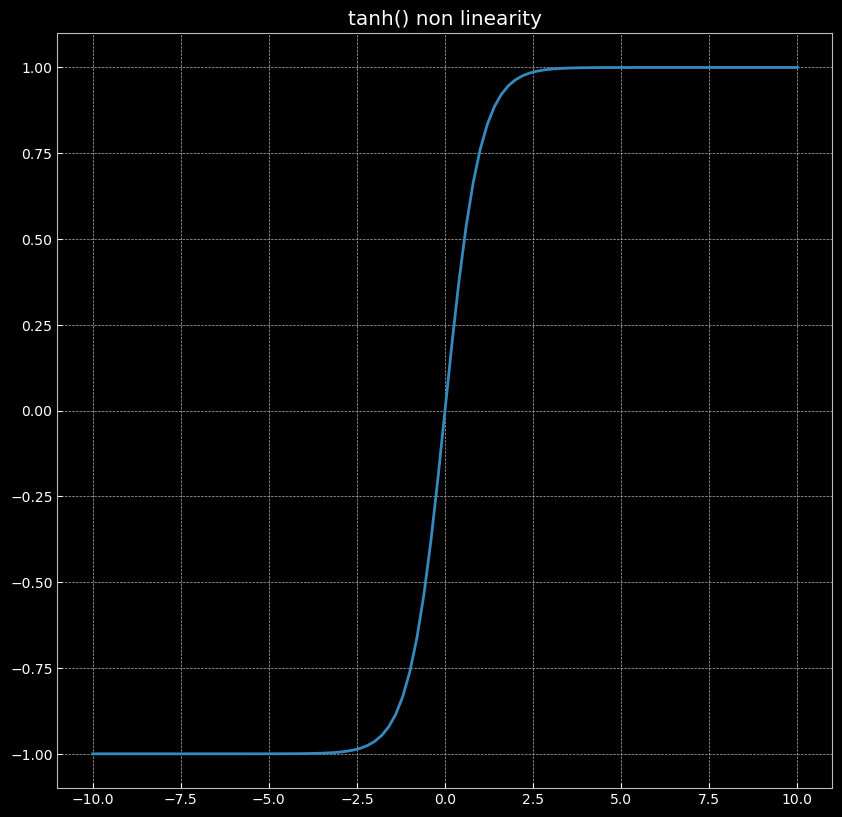

In [10]:
z = torch.linspace(-10, 10, 101)
s = torch.tanh(z)
plot(z.numpy(), s.numpy())
title('tanh() non linearity');

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=False)
  (1): Tanh()
)


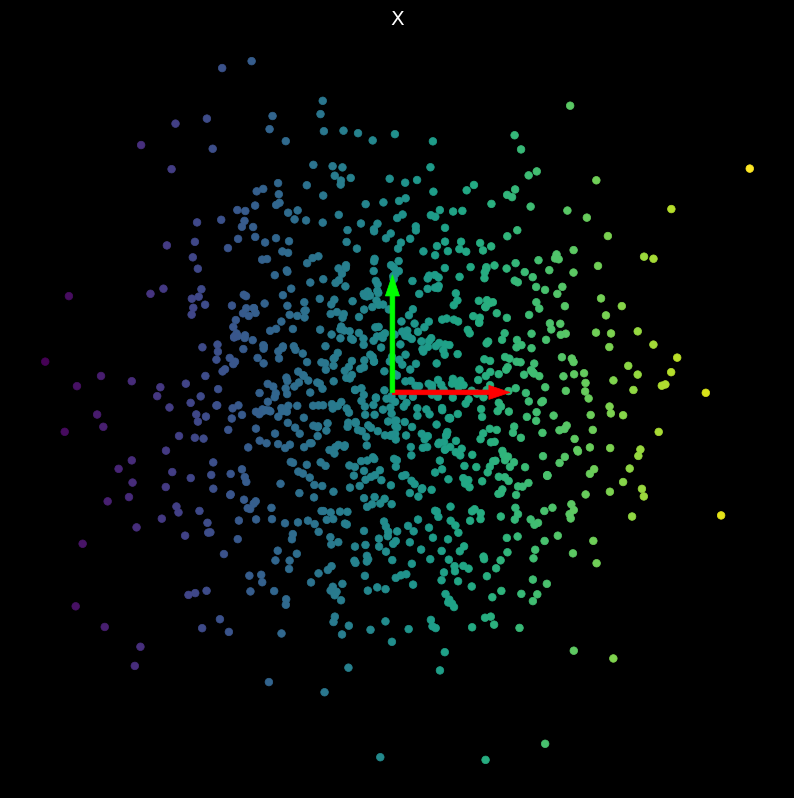

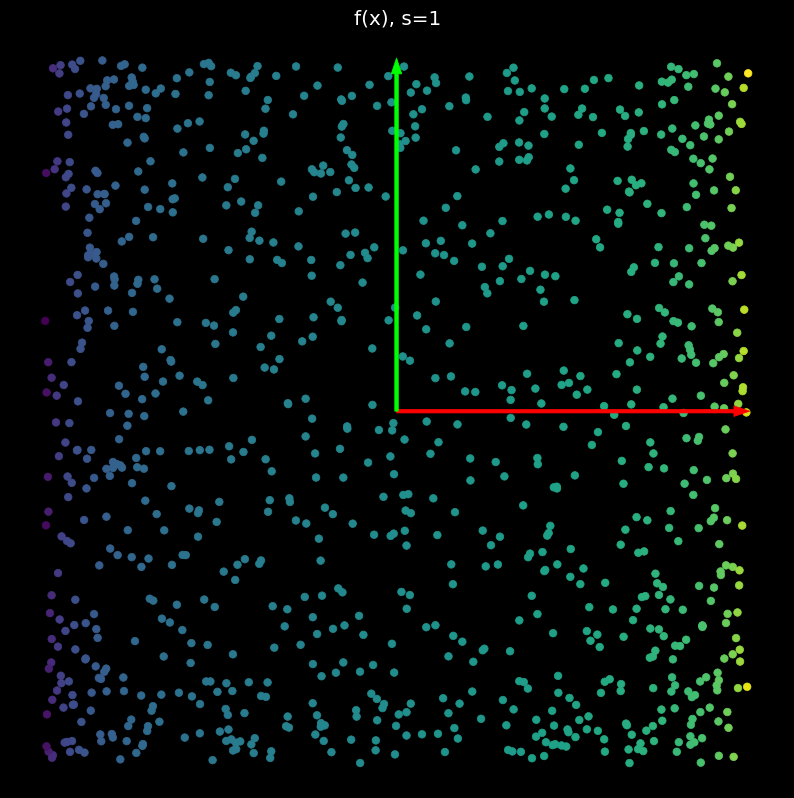

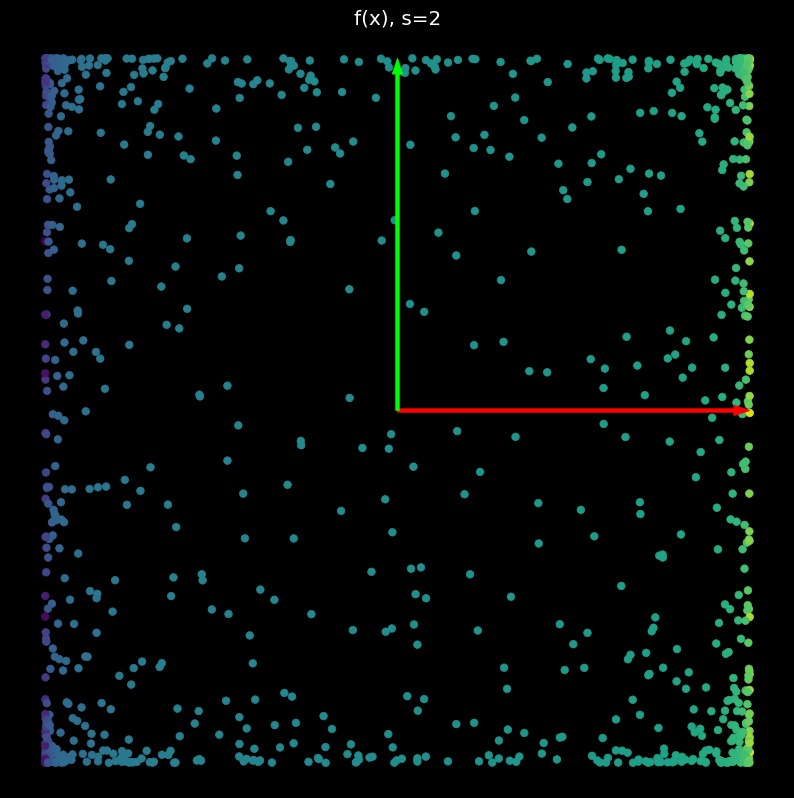

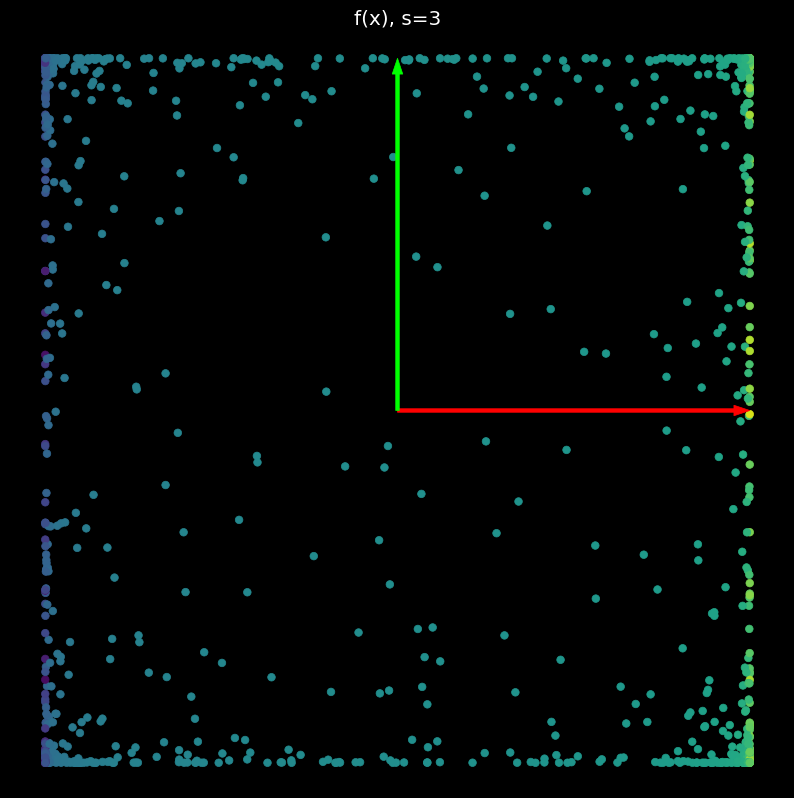

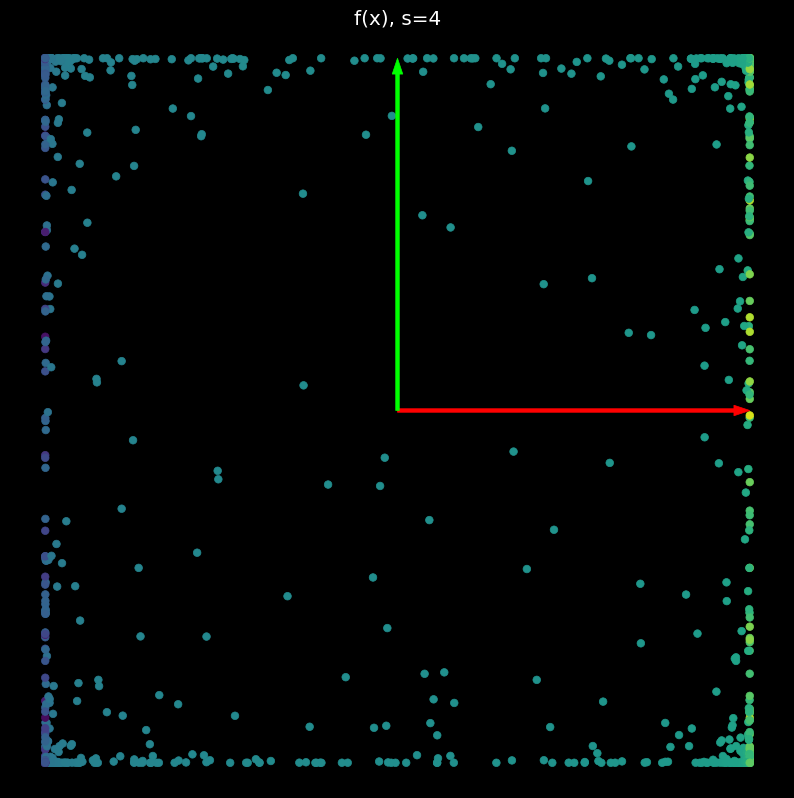

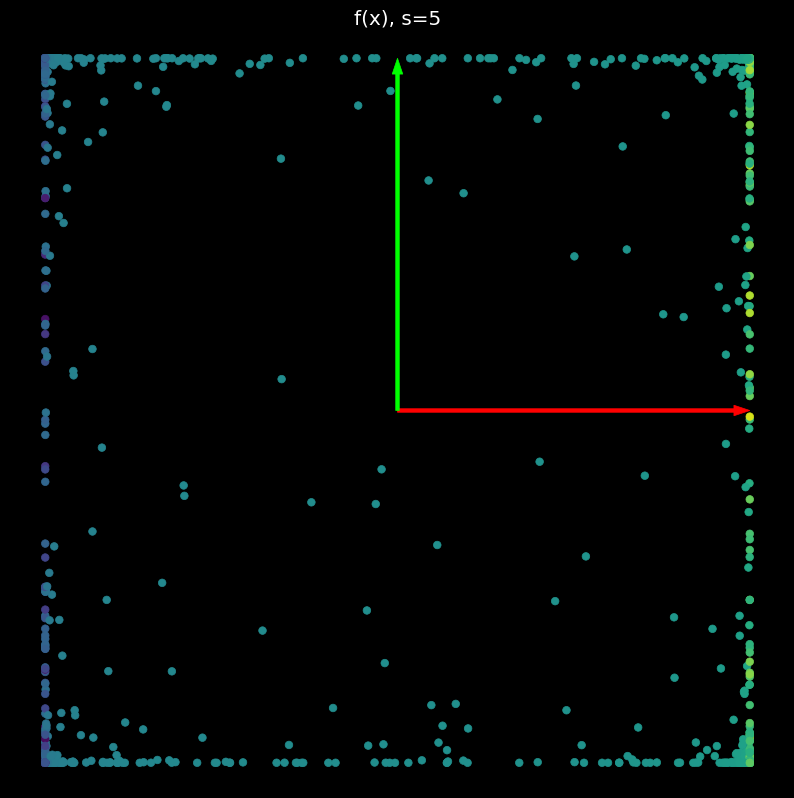

In [11]:
show_scatterplot(X, colors, title='X')
plot_bases(OI)

model = nn.Sequential(
        nn.Linear(2, 2, bias=False),
        nn.Tanh()
)

model.to(device)

print(model)

for s in range(1, 6):
    W = s * torch.eye(2)
    model[0].weight.data.copy_(W)
    Y = model(X).data
    show_scatterplot(Y, colors, title=f'f(x), s={s}')
    plot_bases(OI, width=0.01)

In [12]:
model

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=False)
  (1): Tanh()
)

# Visualize Functions Represented by Random Neural Networks

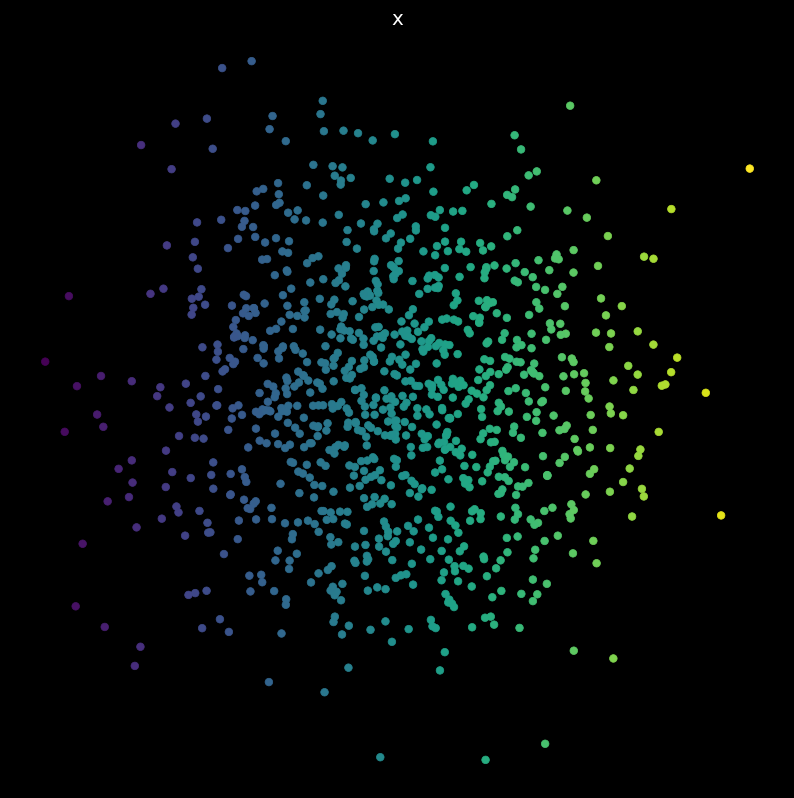

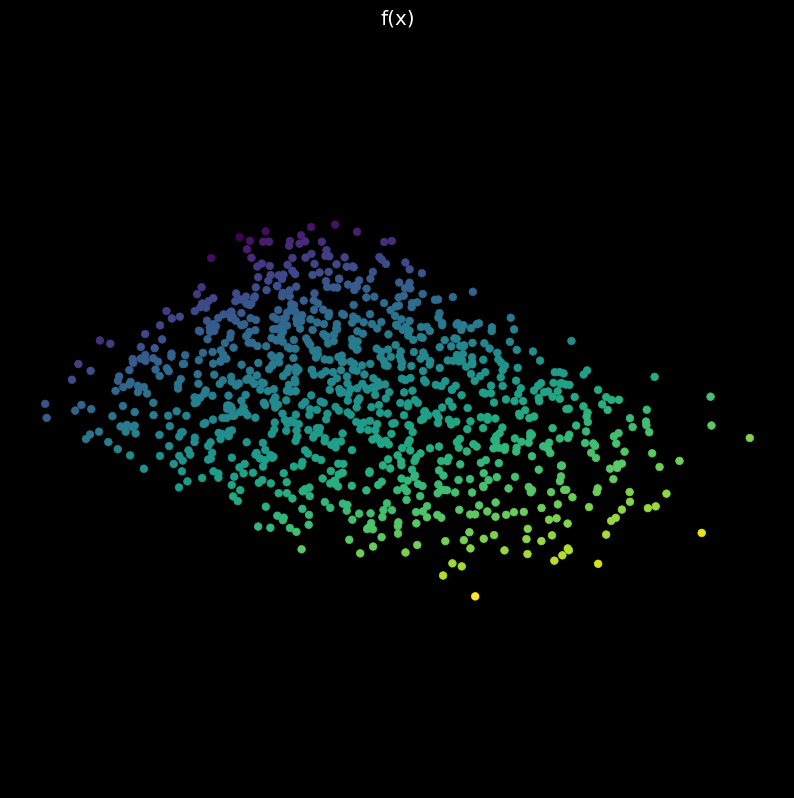

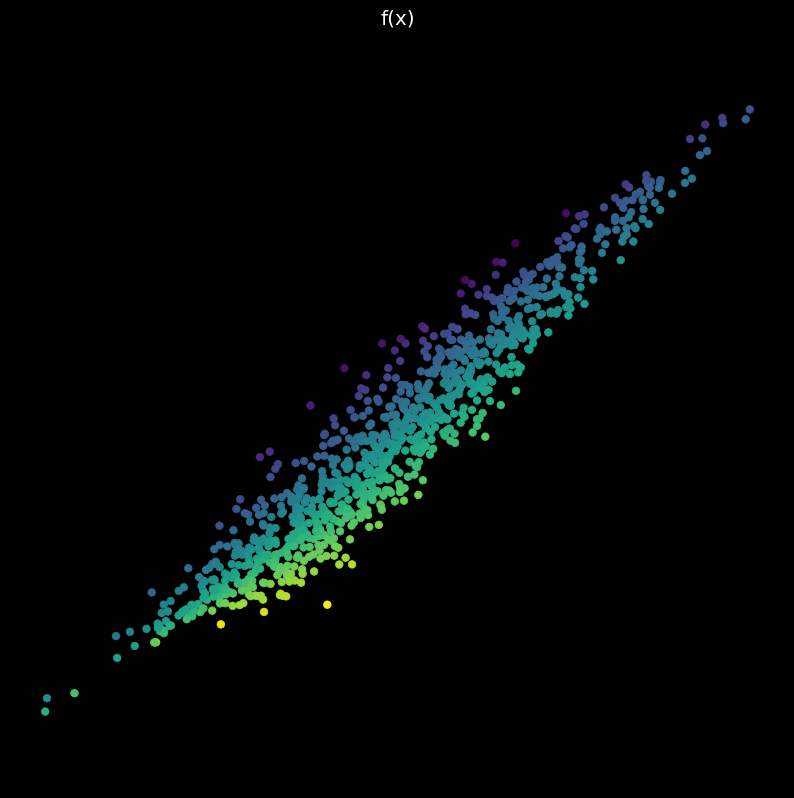

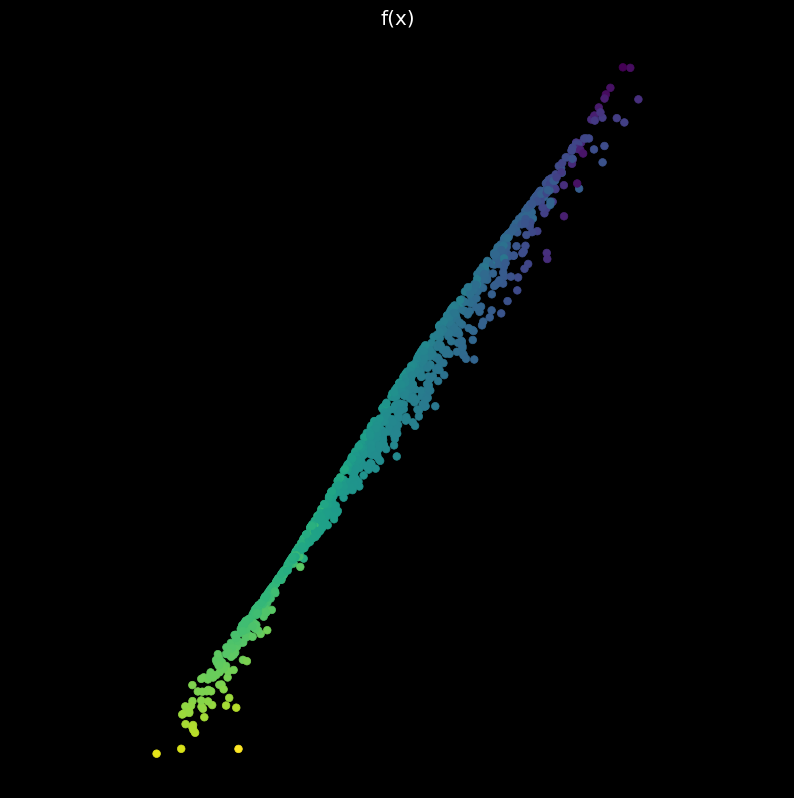

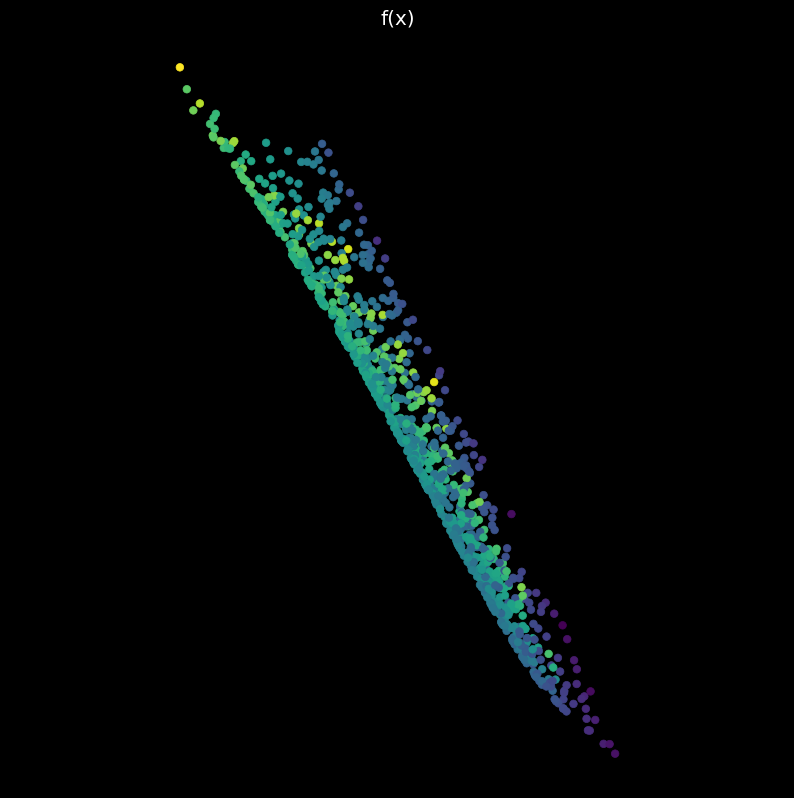

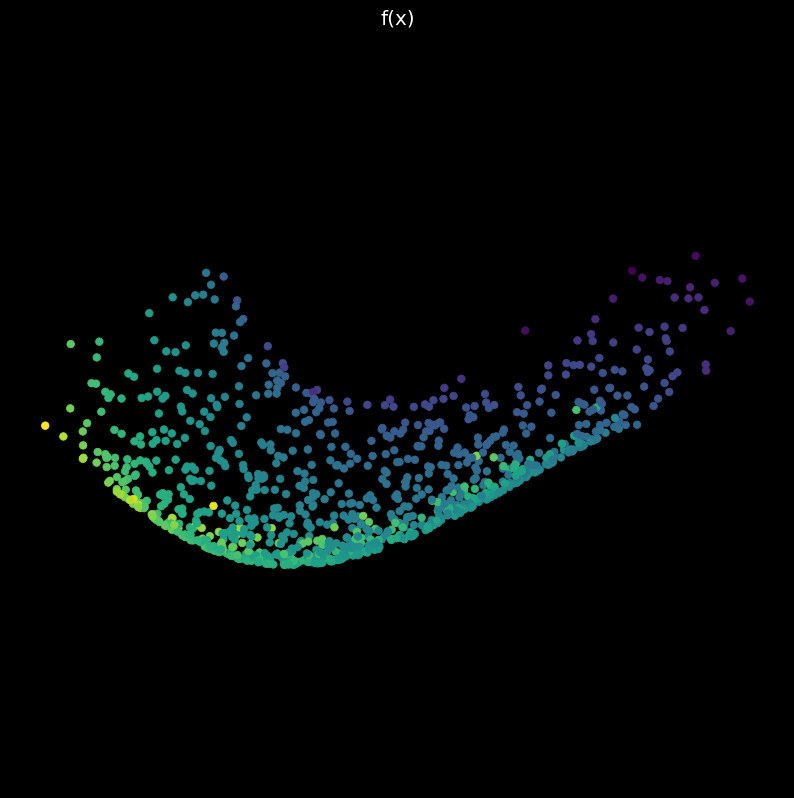

In [13]:
show_scatterplot(X, colors, title='x')
n_hidden = 5

#NL = nn.ReLU()
NL = nn.Tanh()

for i in range(5):
    # create 1-layer neural networks with random weights
    model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
    model.to(device)
    with torch.no_grad():
        Y = model(X)
    show_scatterplot(Y, colors, title='f(x)')
#     plot_bases(OI)

# As an exercise, plot the image of the data in the hidden layer (after applying the activation function) too 

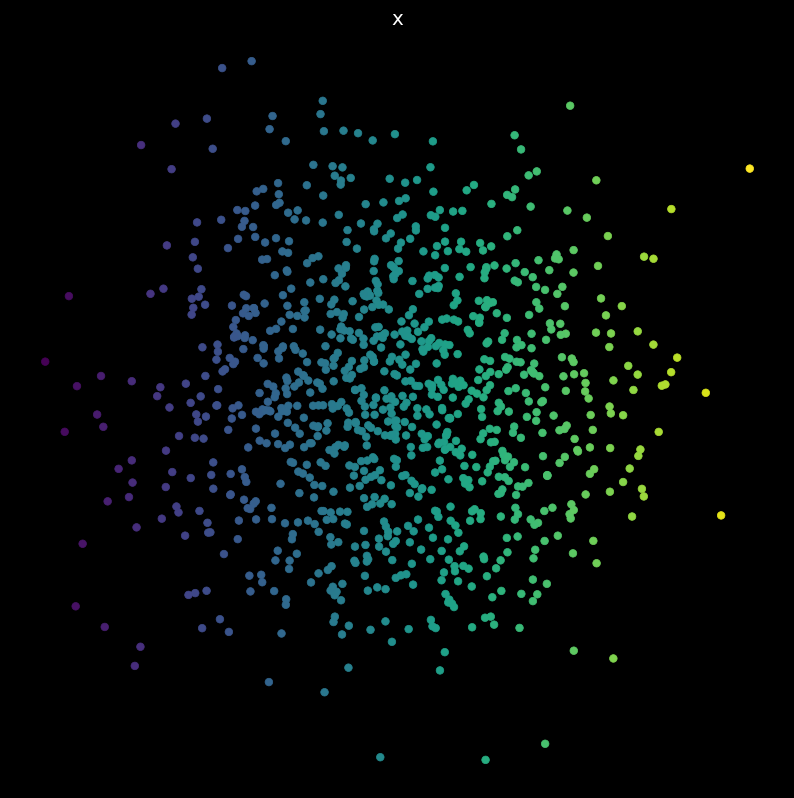

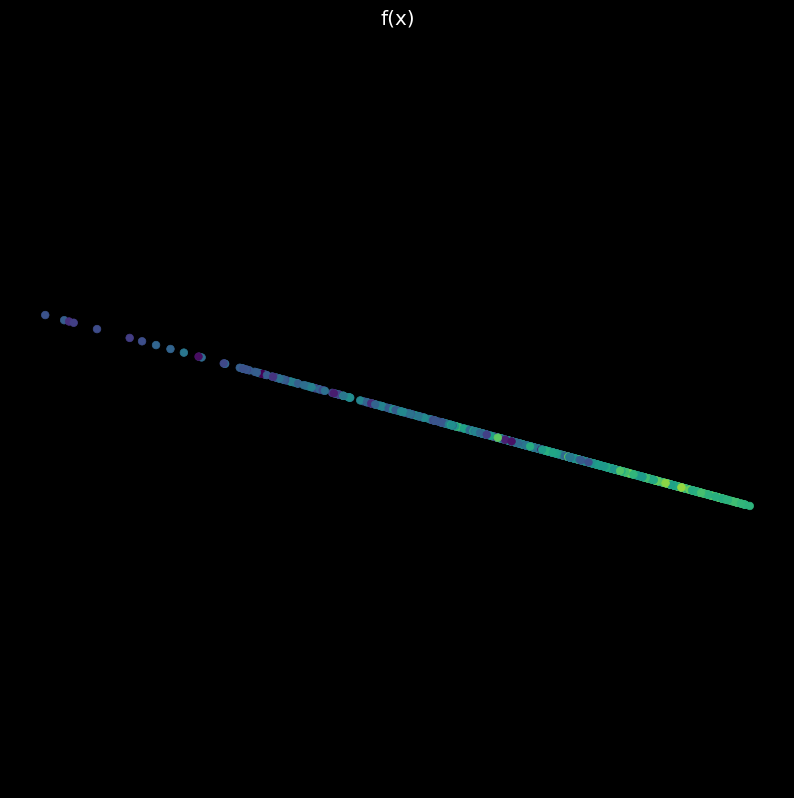

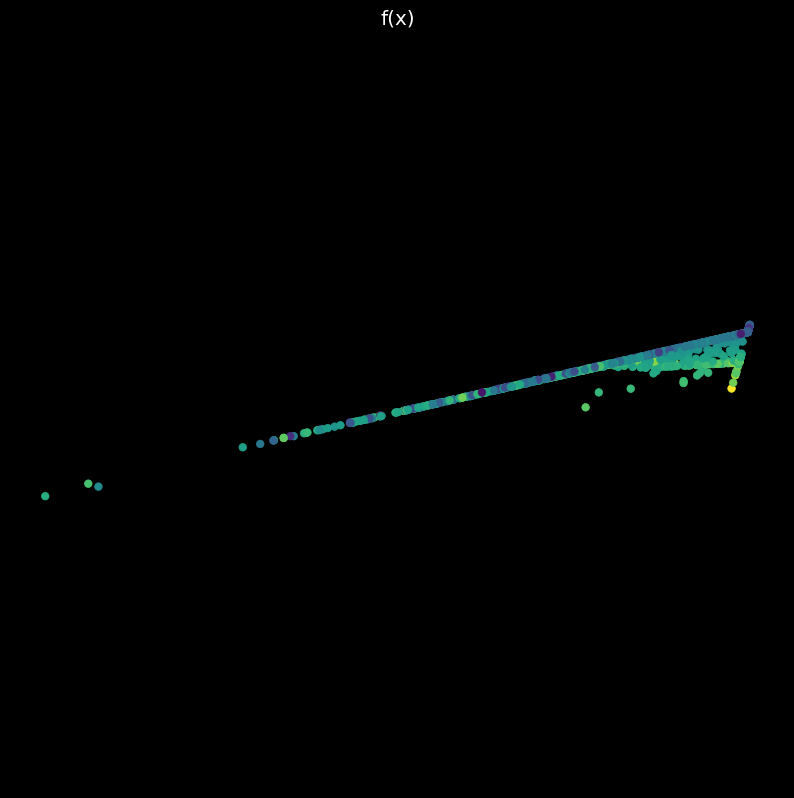

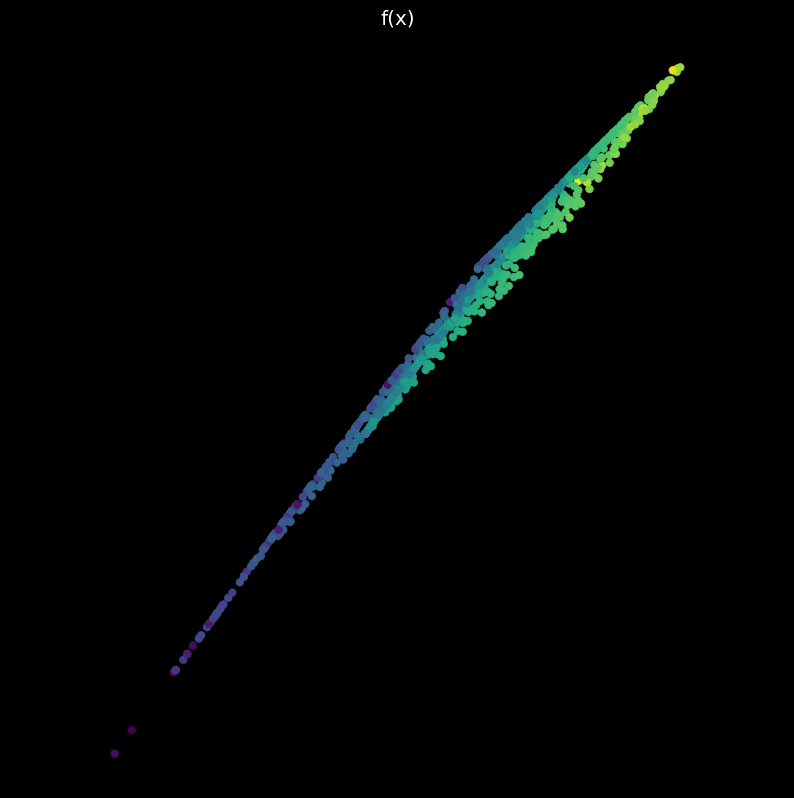

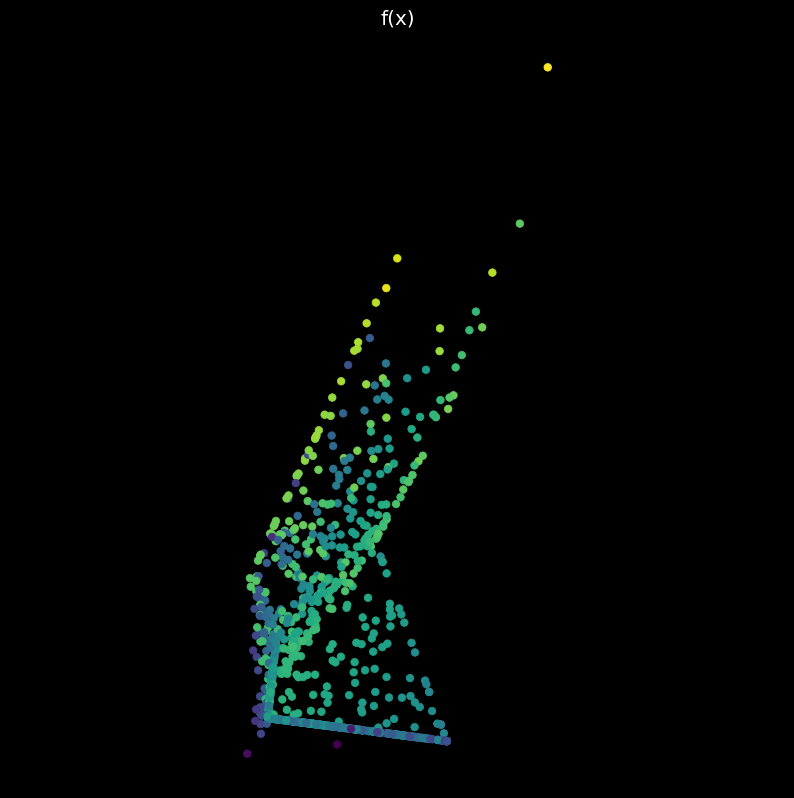

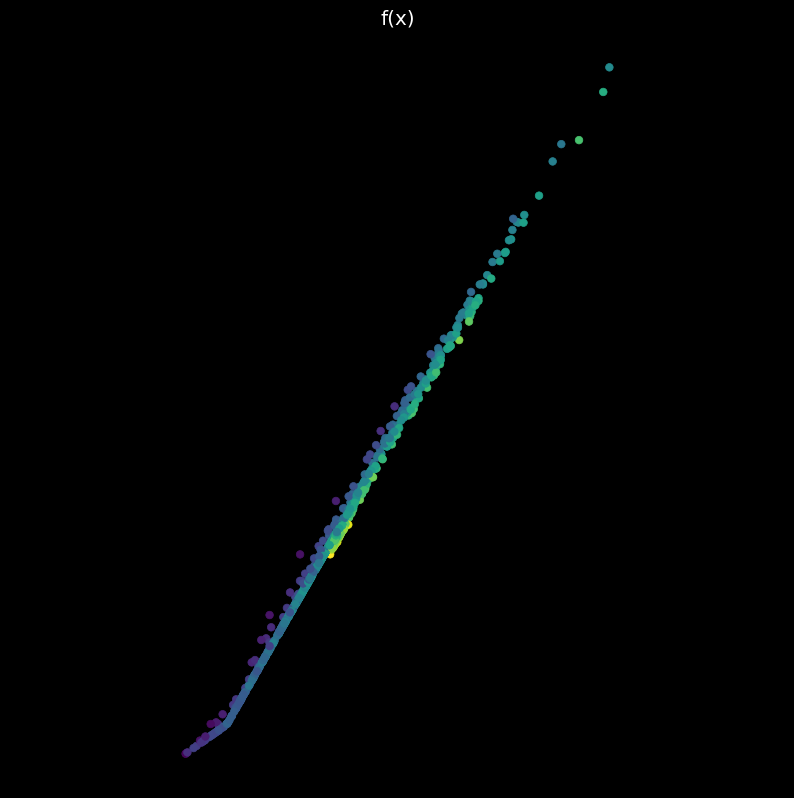

In [14]:
# deeper network with random weights
show_scatterplot(X, colors, title='x')
n_hidden = 5

NL = nn.ReLU()
#NL = nn.Tanh()

for i in range(5):
    model = nn.Sequential(
        nn.Linear(2, n_hidden), 
        NL, 
        nn.Linear(n_hidden, n_hidden), 
        NL, 
        nn.Linear(n_hidden, n_hidden), 
        NL, 
        nn.Linear(n_hidden, n_hidden), 
        NL, 
        nn.Linear(n_hidden, 2)
    )
    model.to(device)
    with torch.no_grad():
        #The detach method detaches the tensor from its computational graph, similar to requires_grad=True
        Y = model(X).detach()
    show_scatterplot(Y, colors, title='f(x)')

In [15]:
model

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=5, bias=True)
  (5): ReLU()
  (6): Linear(in_features=5, out_features=5, bias=True)
  (7): ReLU()
  (8): Linear(in_features=5, out_features=2, bias=True)
)

In [17]:
list(model.children())

[Linear(in_features=2, out_features=5, bias=True),
 ReLU(),
 Linear(in_features=5, out_features=5, bias=True),
 Linear(in_features=5, out_features=5, bias=True),
 Linear(in_features=5, out_features=5, bias=True),
 Linear(in_features=5, out_features=2, bias=True)]

In [19]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.5195,  0.1441],
         [ 0.4241, -0.0806],
         [-0.3263, -0.6412],
         [-0.5890, -0.4841],
         [ 0.1778, -0.2795]], requires_grad=True),
 Parameter containing:
 tensor([ 0.1240,  0.5364, -0.1115, -0.6990, -0.2868], requires_grad=True),
 Parameter containing:
 tensor([[ 0.4076,  0.1931, -0.2299,  0.0216, -0.0691],
         [-0.2918, -0.1527,  0.2896, -0.0503,  0.1046],
         [ 0.3879, -0.1851,  0.0978, -0.1171,  0.0454],
         [-0.2615,  0.0558,  0.2691, -0.1478,  0.1116],
         [-0.2883, -0.0894,  0.2116,  0.1798, -0.0866]], requires_grad=True),
 Parameter containing:
 tensor([ 0.2601, -0.4360, -0.3833,  0.3722,  0.0366], requires_grad=True),
 Parameter containing:
 tensor([[-0.3736,  0.3038, -0.0555,  0.3254, -0.4338],
         [ 0.2356, -0.3865, -0.1651,  0.0860,  0.0357],
         [-0.3970,  0.3882, -0.3024,  0.1565,  0.1136],
         [-0.0440, -0.3658, -0.3548,  0.4201, -0.1142],
         [-0.0739,  0.0799,  0.1754,  0.